In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Libraries loaded!")

✅ Libraries loaded!


In [3]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
df = pd.read_csv(url)
print("Shape:", df.shape)
df.head()

Shape: (90, 18)


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [4]:
print("Columns:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Columns: ['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit', 'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude', 'Class']

Data types:
FlightNumber        int64
Date               object
BoosterVersion     object
PayloadMass       float64
Orbit              object
LaunchSite         object
Outcome            object
Flights             int64
GridFins             bool
Reused               bool
Legs                 bool
LandingPad         object
Block             float64
ReusedCount         int64
Serial             object
Longitude         float64
Latitude          float64
Class               int64
dtype: object


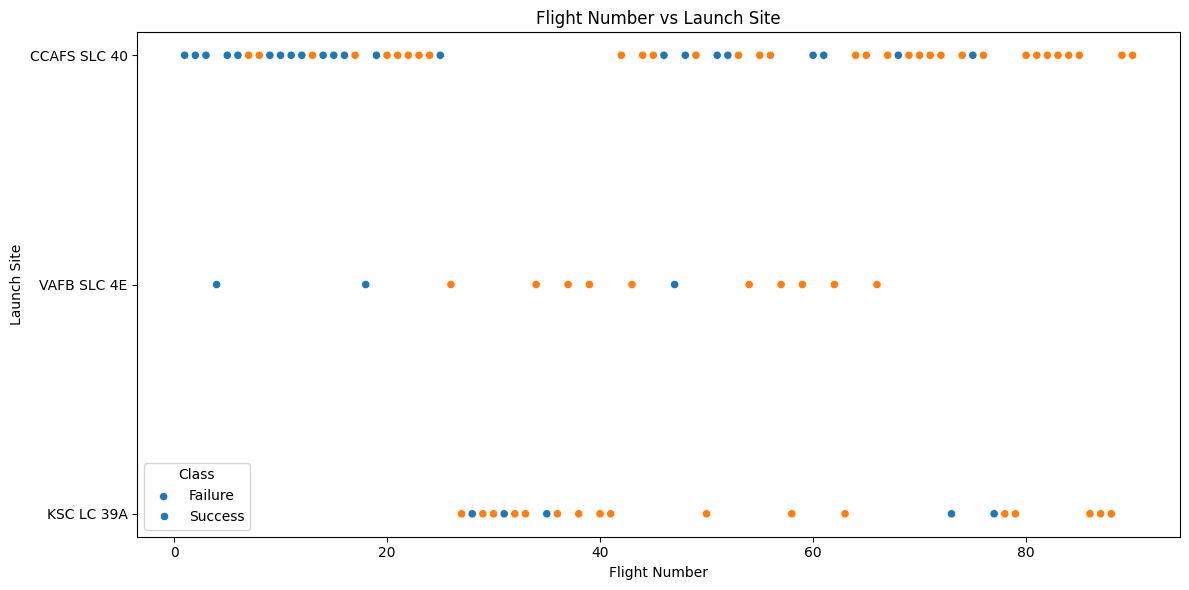

✅ Task 1 Done!


In [5]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=df, x='FlightNumber', y='LaunchSite', hue='Class', marker='o')
plt.xlabel("Flight Number")
plt.ylabel("Launch Site")
plt.title("Flight Number vs Launch Site")
plt.legend(title='Class', labels=['Failure', 'Success'])
plt.tight_layout()
plt.savefig('task1_flightnum_launchsite.png')
plt.show()
print("✅ Task 1 Done!")

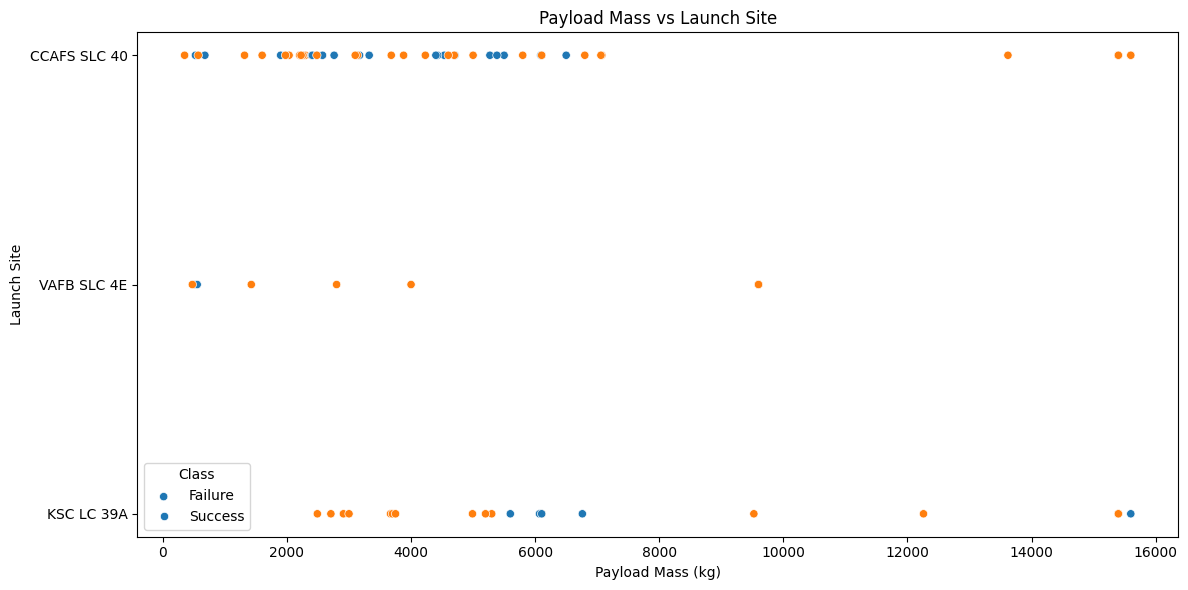

✅ Task 2 Done!


In [6]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=df, x='PayloadMass', y='LaunchSite', hue='Class', marker='o')
plt.xlabel("Payload Mass (kg)")
plt.ylabel("Launch Site")
plt.title("Payload Mass vs Launch Site")
plt.legend(title='Class', labels=['Failure', 'Success'])
plt.tight_layout()
plt.savefig('task2_payload_launchsite.png')
plt.show()
print("✅ Task 2 Done!")

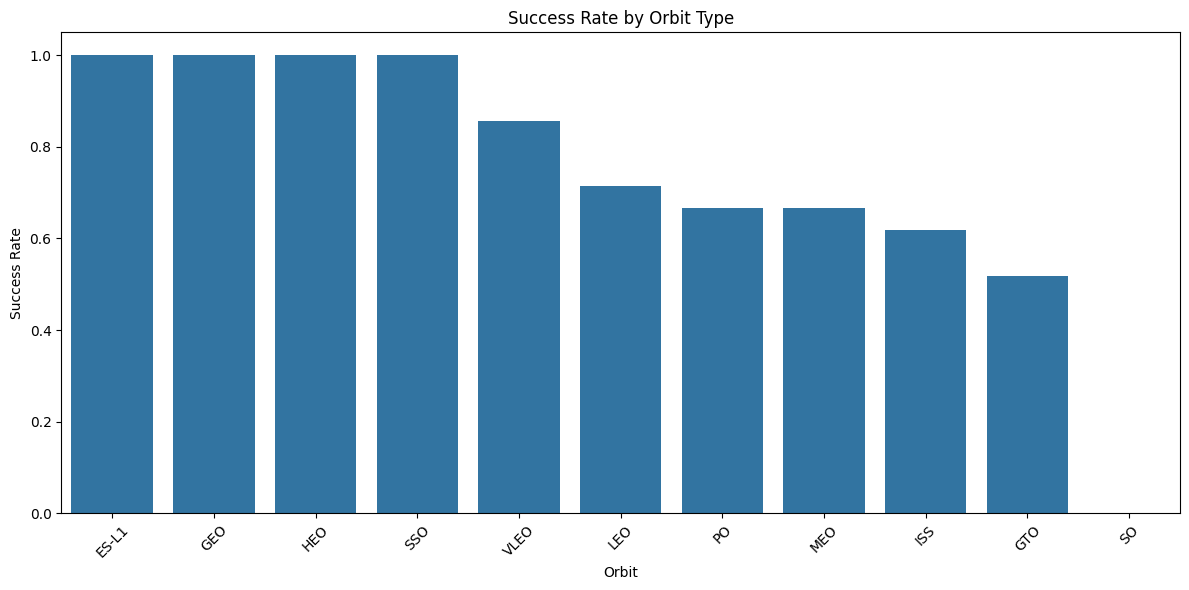

✅ Task 3 Done!
    Orbit  SuccessRate
0   ES-L1     1.000000
1     GEO     1.000000
3     HEO     1.000000
9     SSO     1.000000
10   VLEO     0.857143
5     LEO     0.714286
7      PO     0.666667
6     MEO     0.666667
4     ISS     0.619048
2     GTO     0.518519
8      SO     0.000000


In [7]:
orbit_success = df.groupby('Orbit')['Class'].mean().reset_index()
orbit_success.columns = ['Orbit', 'SuccessRate']
orbit_success = orbit_success.sort_values('SuccessRate', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(data=orbit_success, x='Orbit', y='SuccessRate')
plt.xlabel("Orbit")
plt.ylabel("Success Rate")
plt.title("Success Rate by Orbit Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('task3_success_orbit.png')
plt.show()
print("✅ Task 3 Done!")
print(orbit_success)

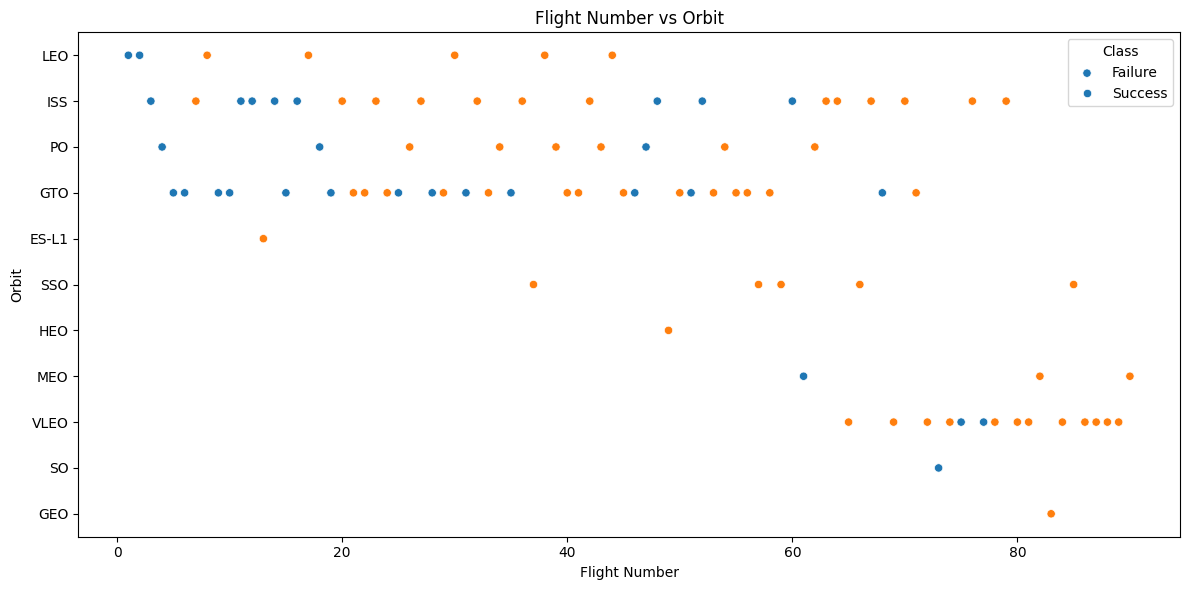

✅ Task 4 Done!


In [8]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=df, x='FlightNumber', y='Orbit', hue='Class', marker='o')
plt.xlabel("Flight Number")
plt.ylabel("Orbit")
plt.title("Flight Number vs Orbit")
plt.legend(title='Class', labels=['Failure', 'Success'])
plt.tight_layout()
plt.savefig('task4_flightnum_orbit.png')
plt.show()
print("✅ Task 4 Done!")

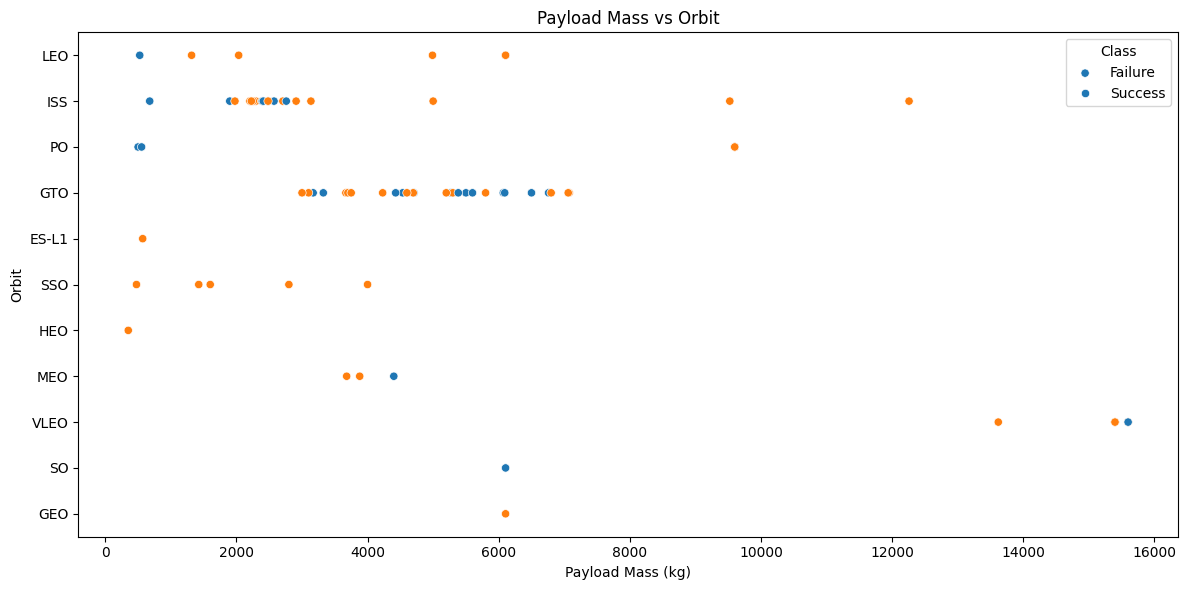

✅ Task 5 Done!


In [9]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=df, x='PayloadMass', y='Orbit', hue='Class', marker='o')
plt.xlabel("Payload Mass (kg)")
plt.ylabel("Orbit")
plt.title("Payload Mass vs Orbit")
plt.legend(title='Class', labels=['Failure', 'Success'])
plt.tight_layout()
plt.savefig('task5_payload_orbit.png')
plt.show()
print("✅ Task 5 Done!")

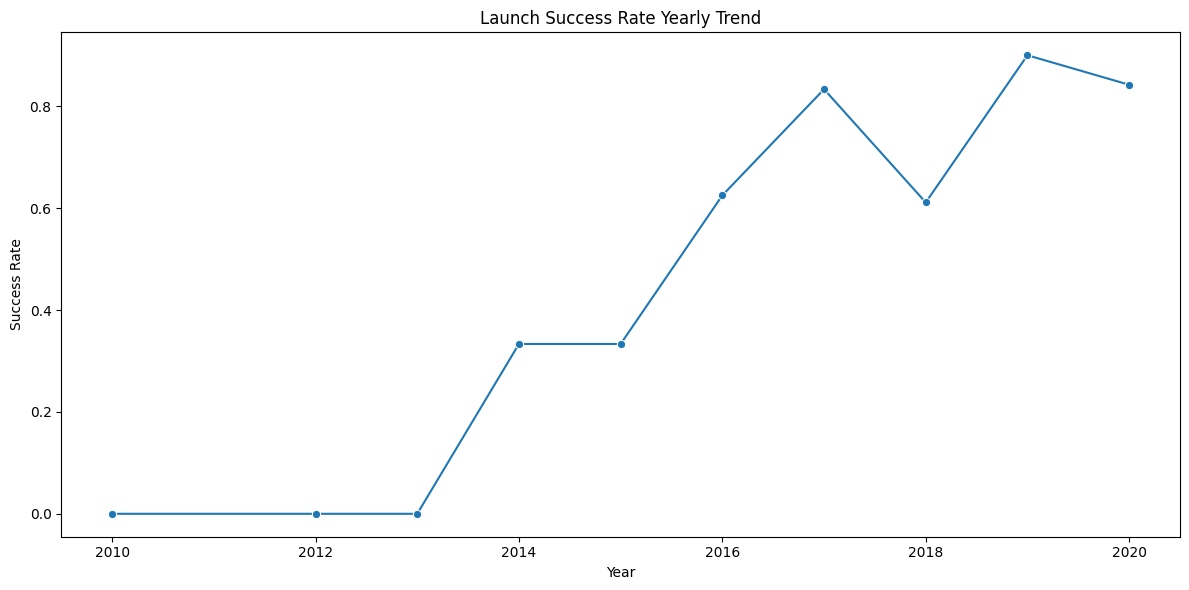

✅ Task 6 Done!
   Year  SuccessRate
0  2010     0.000000
1  2012     0.000000
2  2013     0.000000
3  2014     0.333333
4  2015     0.333333
5  2016     0.625000
6  2017     0.833333
7  2018     0.611111
8  2019     0.900000
9  2020     0.842105


In [10]:
# Convert date to year
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year

yearly_success = df.groupby('Year')['Class'].mean().reset_index()
yearly_success.columns = ['Year', 'SuccessRate']

plt.figure(figsize=(12,6))
sns.lineplot(data=yearly_success, x='Year', y='SuccessRate', marker='o')
plt.xlabel("Year")
plt.ylabel("Success Rate")
plt.title("Launch Success Rate Yearly Trend")
plt.tight_layout()
plt.savefig('task6_yearly_trend.png')
plt.show()
print("✅ Task 6 Done!")
print(yearly_success)

/tmp/ipykernel_340/163776998.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
/tmp/ipykernel_340/163776998.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)


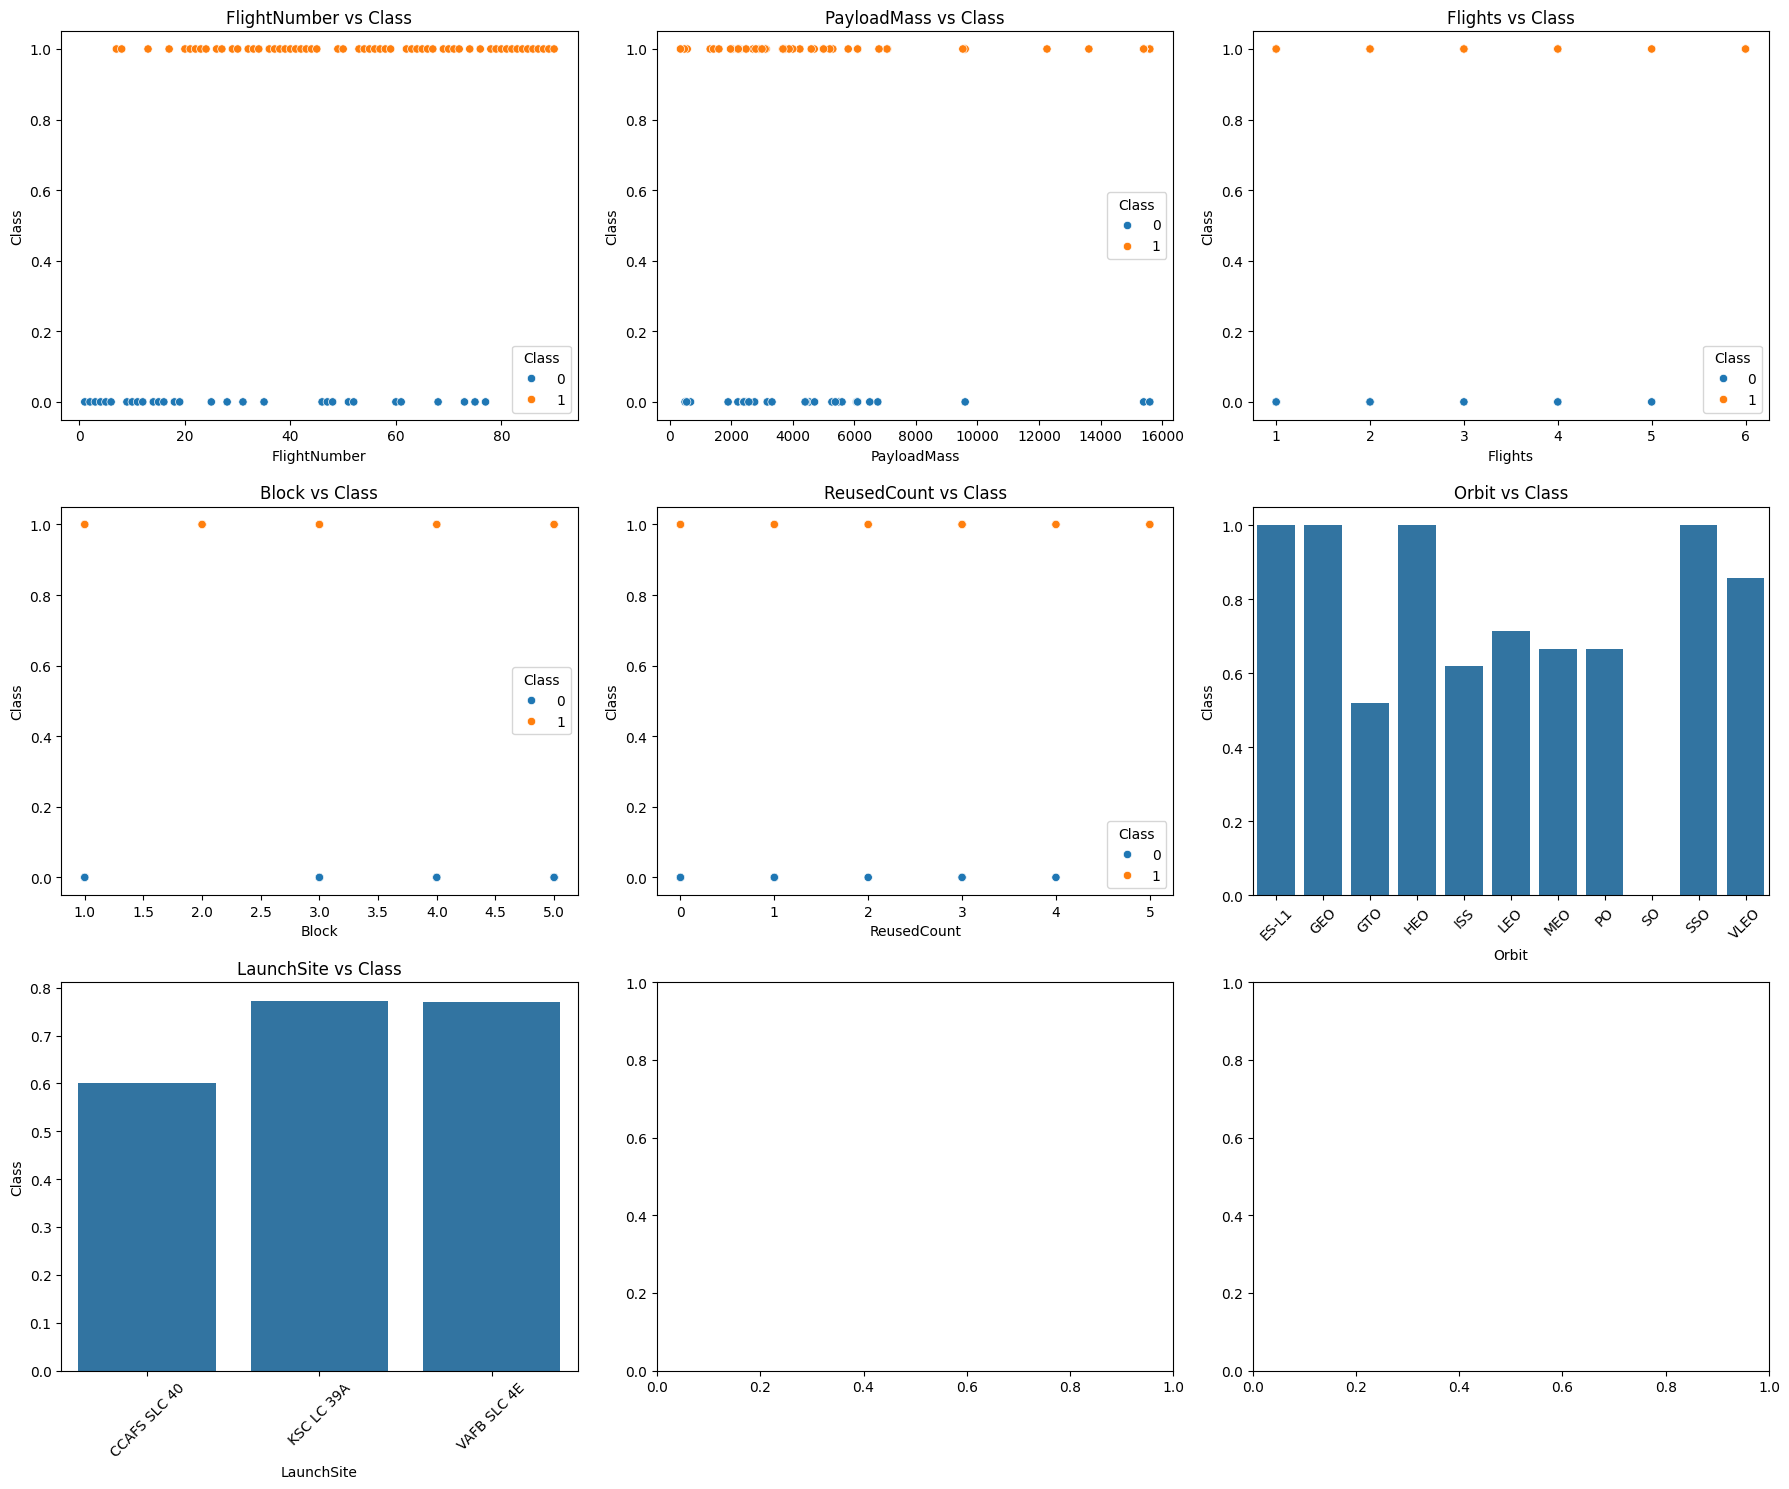

✅ Task 7 Done!


In [11]:
features = ['FlightNumber', 'PayloadMass', 'Flights', 'Block', 'ReusedCount', 'Orbit', 'LaunchSite']

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, feature in enumerate(features):
    if df[feature].dtype == 'object':
        success_rate = df.groupby(feature)['Class'].mean().reset_index()
        sns.barplot(data=success_rate, x=feature, y='Class', ax=axes[i])
        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
    else:
        sns.scatterplot(data=df, x=feature, y='Class', hue='Class', ax=axes[i])
    axes[i].set_title(f'{feature} vs Class')

plt.tight_layout()
plt.savefig('task7_all_features.png')
plt.show()
print("✅ Task 7 Done!")

In [12]:
import shutil
shutil.copy('task1_flightnum_launchsite.png', '/content/drive/MyDrive/task1_flightnum_launchsite.png')
shutil.copy('task6_yearly_trend.png', '/content/drive/MyDrive/task6_yearly_trend.png')
print("✅ All plots saved to Google Drive!")

✅ All plots saved to Google Drive!
